# Rainfall Testing - Kottakudi (2025)
Visualizing the daily rainfall data extracted from the IMD gridded binary files.
Comparing **Nearest Neighbor** vs **Bilinear Interpolation** methods.

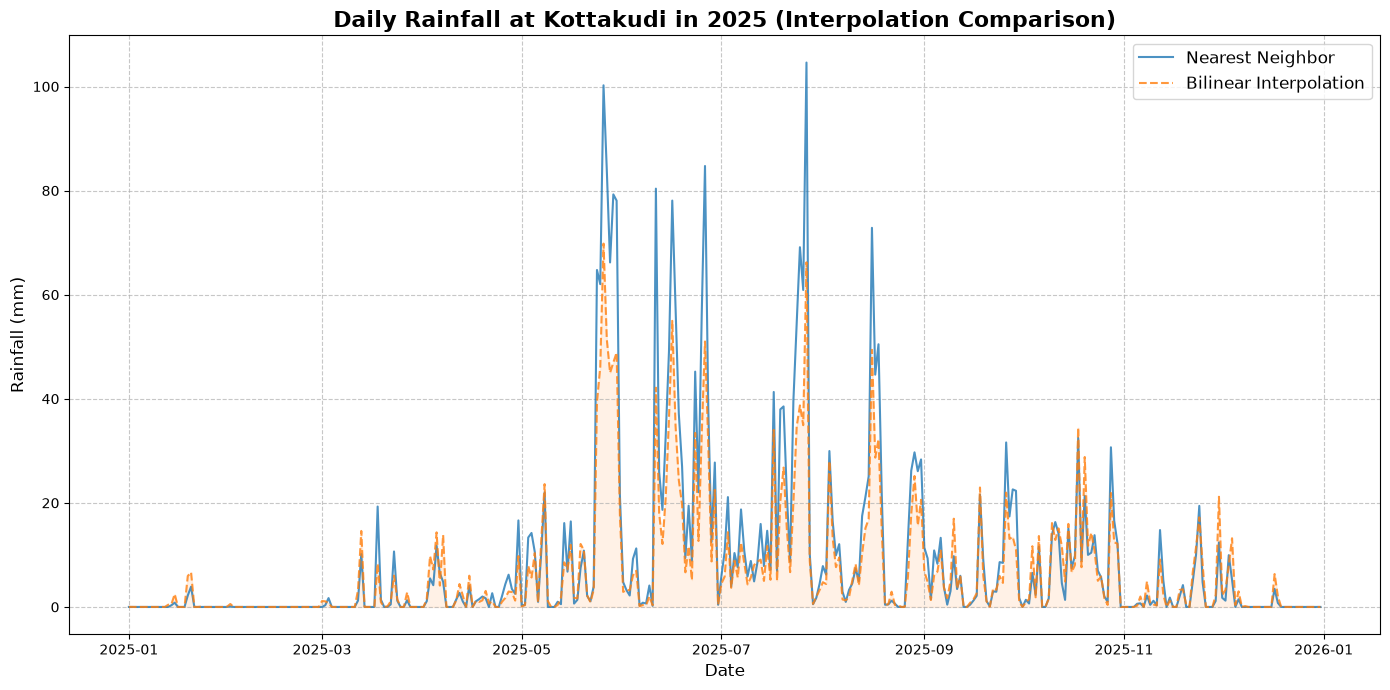

Total Rainfall (Nearest Neighbor): 3380.68 mm
Total Rainfall (Bilinear Interpolation): 2542.94 mm


In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import os

# Ensure the CSV exists
# csv_path = '../uploaded_docs/kottakudi_rainfall_2025.csv'
csv_path = '../uploaded_docs/devikulam_rainfall_2025.csv'
# csv_path ="/home/v252lin/SanthoshM_Works/CardamomBusiness_1/kottakudi_rainfall_2025.csv"
if not os.path.exists(csv_path):
    print(f"Data file not found at {csv_path}. Please run the scraper script first!")
else:
    # Load the extracted rainfall data for Kottakudi
    df = pd.read_csv(csv_path, parse_dates=['Date'])
    
    # Plotting
    plt.figure(figsize=(14, 7))
    plt.plot(df['Date'], df['Rainfall_Nearest_mm'], color='#1f77b4', linewidth=1.5, label='Nearest Neighbor', alpha=0.8)
    plt.plot(df['Date'], df['Rainfall_Bilinear_mm'], color='#ff7f0e', linewidth=1.5, linestyle='--', label='Bilinear Interpolation', alpha=0.8)
    
    # Aesthetics
    plt.title('Daily Rainfall at Kottakudi in 2025 (Interpolation Comparison)', fontsize=16, fontweight='bold')
    plt.xlabel('Date', fontsize=12)
    plt.ylabel('Rainfall (mm)', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.legend(fontsize=12)
    
    # Fill the area under the curve for the Bilinear method
    plt.fill_between(df['Date'], df['Rainfall_Bilinear_mm'], color='#ff7f0e', alpha=0.1)
    
    plt.tight_layout()
    plt.show()
    
    # Print the totals for comparison
    print(f"Total Rainfall (Nearest Neighbor): {df['Rainfall_Nearest_mm'].sum():.2f} mm")
    print(f"Total Rainfall (Bilinear Interpolation): {df['Rainfall_Bilinear_mm'].sum():.2f} mm")


## monthly rainfall

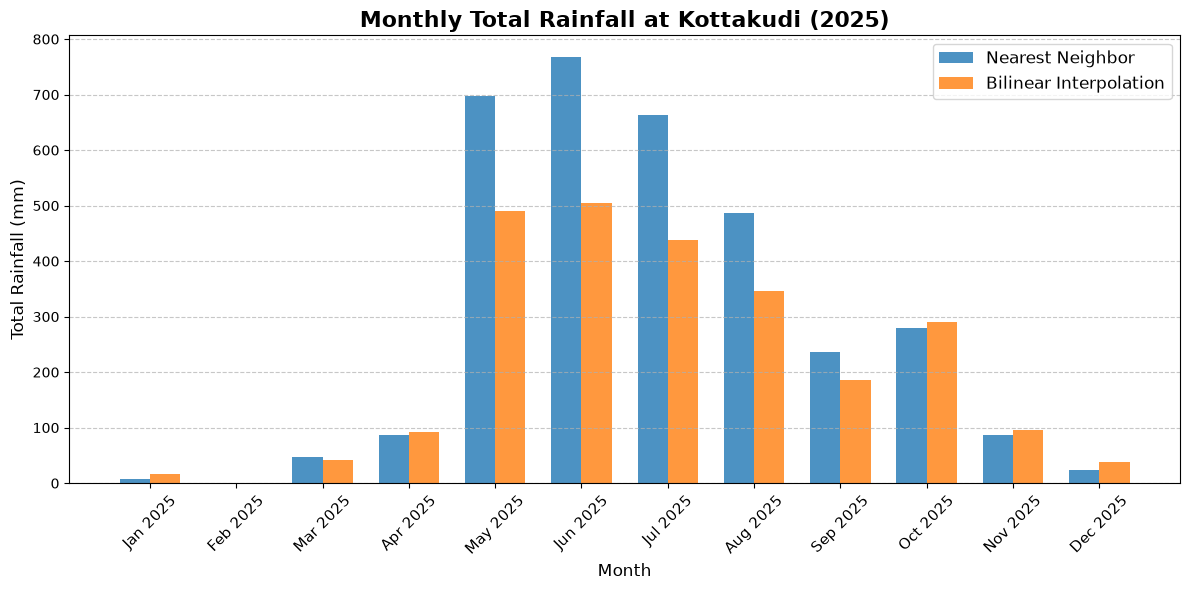

In [5]:
# Group by month and calculate total rainfall
df['Month'] = df['Date'].dt.to_period('M')
monthly_rainfall = df.groupby('Month')[['Rainfall_Nearest_mm', 'Rainfall_Bilinear_mm']].sum()
monthly_rainfall.index = monthly_rainfall.index.strftime('%b %Y')

# Plotting monthly column chart (bar chart)
fig, ax = plt.subplots(figsize=(12, 6))
width = 0.35
x = range(len(monthly_rainfall))

ax.bar([i - width/2 for i in x], monthly_rainfall['Rainfall_Nearest_mm'], width, label='Nearest Neighbor', color='#1f77b4', alpha=0.8)
ax.bar([i + width/2 for i in x], monthly_rainfall['Rainfall_Bilinear_mm'], width, label='Bilinear Interpolation', color='#ff7f0e', alpha=0.8)

ax.set_xlabel('Month', fontsize=12)
ax.set_ylabel('Total Rainfall (mm)', fontsize=12)
ax.set_title('Monthly Total Rainfall at Kottakudi (2025)', fontsize=16, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(monthly_rainfall.index, rotation=45, fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.7)
ax.legend(fontsize=12)

plt.tight_layout()
plt.show()


## Bangalore Rain Fall Data Refetence

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the dataset
# Adjust the path if you are running this from a different folder level
df_bangalore = pd.read_csv('../uploaded_docs/BangaloreRainFallData.csv')

# 2. Set the year parameter (Change this to plot different years)
target_year = 2025

# 3. Filter the data for the specified year
# year_data = df_bangalore[df_bangalore['Year'] == target_year]
# To this:
year_data = df_bangalore[df_bangalore['Year'].astype(str) == str(target_year)]

if not year_data.empty:
    # 4. Extract the monthly columns
    months = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'June', 'July', 'Aug', 'Sept', 'Oct', 'Nov', 'Dec']
    rainfall_values = year_data.iloc[0][months].values
    
    # 5. Plot the data as a column chart
    fig, ax = plt.subplots(figsize=(12, 6))
    bars = ax.bar(months, rainfall_values, color='#2ca02c', alpha=0.8)
    
    # Add styling and labels
    ax.set_title(f'Monthly Rainfall in Bangalore for {target_year}', fontsize=16, fontweight='bold')
    ax.set_xlabel('Month', fontsize=12)
    ax.set_ylabel('Rainfall (mm)', fontsize=12)
    ax.grid(axis='y', linestyle='--', alpha=0.7)
    
    # Optional: Add the exact value labels on top of each bar
    for bar in bars:
        height = bar.get_height()
        if height > 0: # Only label bars that have rainfall
            ax.text(bar.get_x() + bar.get_width()/2., height + 1,
                    f'{height}', ha='center', va='bottom', fontsize=10)
            
    plt.tight_layout()
    plt.show()
else:
    print(f"Data for the year {target_year} is not available in the dataset.")


Data for the year 2025 is not available in the dataset.


In [8]:
df_bangalore

,_id,Year,Jan,Feb,Mar,Apr,May,June,July,Aug,Sept,Oct,Nov,Dec,Total,El NiNo (Y/N),La Nina (Y/N)
0,1,1901,0.0,78.9,0.0,24.3,146.0,47.7,71.6,71.6,318.5,120.3,37.3,23.1,939.3,Y,N
1,2,1902,0.7,0.0,17.0,58.1,197.8,62.2,32.0,79.5,213.6,219.9,11.1,25.4,917.3,N,N
2,3,1903,0.0,0.0,0.0,1.5,63.7,109.2,27.9,189.7,475.2,171.1,233.6,29.4,1301.3,Y,N
3,4,1904,0.5,0.0,0.0,14.4,241.5,49.5,149.3,53.8,126.4,157.2,0.0,1.7,794.3,N,Y
4,5,1905,1.7,0.0,56.6,32.7,90.6,60.7,58.9,266.4,62.4,227.8,29.2,3.0,890.0,N,N
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
122,123,2023,0.0,0.0,8.4,28.2,305.5,72.3,141.5,12.6,248.4,96.0,106.6,0.7,1020.2,Y,N
123,124,2024,0.0,0.0,0.0,0.0,180.9,204.7,92.8,230.2,23.9,306.2,21.6,93.7,1154.0,Y,Y
124,125,2025,5.2,0.0,11.8,32.3,315.0,58.0,87.5,161.8,242.0,127.9,2.3,1.2,1045.0,Y,Y
125,126,LPA (1991-2020),1.7,5.9,19.2,73.0,133.0,111.0,112.8,160.2,198.4,180.7,63.4,14.8,1077.1,NaN,NaN
